# NeXo v3.0 · Notebook 04 — RAT Underservice (XGBoost binary classifier)

> **CRISP-DM Phase 4 — Modeling** · Supervised binary classification.
> **Input:** `curated/subscribers.parquet` + `splits.json` (from nb 01).
> **Output:** `models/rat_underservice_v3_xgb.joblib` + `rat_v3_feature_names.joblib` + model card.
> **Consumed by:** `services/ai-service/model_cache.py` (mtime hot-reload) → `POST /infer/rat-underservice`.

## What problem does this model solve?
A **RAT-underserved** subscriber is one whose handset is **4G-capable but consumes
mostly 2G/3G traffic** — they paid for premium hardware/plan but experience inferior
service. Business consequence: low NPS, churn risk, recoverable revenue.

The label is a closed-form score from nb 01:
```
rat_gap_score = is_4g_capable × (1 − traffic_share_4g)    ∈ [0,1]
label         = (rat_gap_score > 0.30)                    ∈ {0,1}
```
If we could always compute `rat_gap_score` at inference time, no ML would be needed —
just threshold the score. The ML model exists for the scenarios where you **cannot**:
1. RAT-share data is stale / delayed in the OSS pipeline.
2. A new subscriber has no usage history yet.
3. Real-time L4 playbooks (`pb-churn-prevention`) need a score from cached
   subscriber features without waiting on the next ETL tick.

So the model must learn underservice from **behavioral, device, location, ARPU,
voice/SMS signals** — explicitly EXCLUDING the formula inputs. Keeping the formula
inputs is **label leakage**: the model trivially re-derives the answer and reports
ROC-AUC ≈ 1.0, which means nothing.

## Pipeline
```
subscribers.parquet  →  label (rat_gap_score > 0.30)
                    →  drop label inputs + near-perfect proxies (anti-leakage)
                    →  XGBoost (regularized, early-stopped on val AUC)
                    →  eval on random + temporal splits + 5-fold CV (honesty check)
                    →  calibration + threshold sweep
                    →  save .joblib + feature names + model card
```

## Why XGBoost
- Tabular gold-standard — boosted trees beat deep nets on structured features.
- GPU-accelerated (`device='cuda'`, `tree_method='hist'`), automatic CPU fallback.
- Class-imbalance via `scale_pos_weight`.
- Native early-stopping → picks best boosting round, prevents over-capacity.

## XGBoost terminology (important)
- **Boosting rounds** (`n_estimators`) = number of trees in the ensemble. NOT "epochs".
- Each round adds one tree fitted on the residuals of the previous ensemble.
- More rounds ⇒ **more capacity ⇒ MORE overfit risk**, not less.
- Overfit defense in XGBoost: `early_stopping_rounds`, `max_depth`, `subsample`,
  `colsample_bytree`, `reg_lambda`, `gamma` — NOT a bigger `n_estimators`.

## Two evaluation regimes (both reported)
- **Random split** — best-case metric.
- **Temporal hold-out** — train on early months, test on the last → drift realism.
- **+ 5-fold CV** on a subsample — honesty check, surfaces hidden leakage.

## What this notebook does NOT do
- Does NOT compute the CEM score (nb 02) or OSS anomalies (nb 03).
- Does NOT define `rat_gap_score` — that's a feature from nb 01; here we threshold it.
- Does NOT deploy — writes the joblib artifact ai-service hot-loads.

## 1 · Imports + MinIO load

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
from IPython.display import display

import io, json, os
from pathlib import Path
import boto3, joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import xgboost as xgb
from botocore.client import Config
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_recall_curve, auc
sns.set_theme(style='whitegrid')
s3 = boto3.client('s3', endpoint_url=os.environ.get('S3_ENDPOINT','http://localhost:9000'),
                  aws_access_key_id='minio', aws_secret_access_key='minio_pw',
                  config=Config(signature_version='s3v4'))
subs = pd.read_parquet(io.BytesIO(s3.get_object(Bucket='curated', Key='subscribers.parquet')['Body'].read()))
splits = json.loads(s3.get_object(Bucket='curated', Key='splits.json')['Body'].read())
print(f'subs: {len(subs):,} rows  splits: {splits["meta"]["random_sizes"]}')

subs: 7,608,898 rows  splits: {'train': 5329271, 'val': 1138292, 'test': 1141335}


In [2]:
# ── Parameters (papermill-overridable) ──────────────────────────────────────
# This cell is tagged `parameters`. retrain-service (papermill) can override any
# value without editing the notebook. EVERY magic number lives here.
import os, random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Label definition
RAT_LABEL_THRESHOLD = 0.30   # subscriber flagged underserved if rat_gap_score > this

# XGBoost hyperparameters
# NOTE: XGBoost has BOOSTING ROUNDS (n_estimators), not "epochs".
# Each round adds one tree fit on the residuals of the previous ensemble.
# More rounds ⇒ MORE capacity ⇒ MORE overfit. The real overfit defense is
# `early_stopping_rounds` on a held-out val set + regularization (subsample,
# colsample, reg_lambda, gamma) — NOT bigger n_estimators.
XGB_N_ESTIMATORS    = 800     # upper cap; early-stopping picks best round
XGB_MAX_DEPTH       = 6       # shallower than before (was 8) — anti-overfit
XGB_LEARNING_RATE   = 0.05    # smaller lr + more rounds = smoother convergence
XGB_OBJECTIVE       = 'binary:logistic'
XGB_EVAL_METRIC     = 'auc'
XGB_TREE_METHOD     = 'hist'  # histogram split-finding (GPU-friendly)
XGB_SUBSAMPLE       = 0.8     # row sampling per tree (bagging-style regularizer)
XGB_COLSAMPLE       = 0.8     # column sampling per tree
XGB_REG_LAMBDA      = 1.0     # L2 leaf-weight penalty
XGB_GAMMA           = 0.1     # min loss reduction to split (pruning)
EARLY_STOP_ROUNDS   = 25      # stop if val AUC stagnates for N rounds

# Decision + reporting
DECISION_THRESHOLD   = 0.50   # probability cutoff for the F1 operating point
TOP_K_IMPORTANCE     = 20     # features shown in the importance chart
CV_FOLDS             = 5      # honesty check — out-of-fold ROC-AUC on a subsample

# Artifact filenames — IMMUTABLE (services/ai-service/model_cache.py reads these)
RAT_MODEL_FNAME  = 'rat_underservice_v3_xgb.joblib'
RAT_FEATS_FNAME  = 'rat_v3_feature_names.joblib'
RAT_CARD_FNAME   = 'rat_underservice_v3_model_card.md'

print(f'SEED={SEED} | label>{RAT_LABEL_THRESHOLD} | '
      f'xgb=≤{XGB_N_ESTIMATORS}t/depth{XGB_MAX_DEPTH}/lr{XGB_LEARNING_RATE} | '
      f'early_stop={EARLY_STOP_ROUNDS} | cv={CV_FOLDS}-fold | thr={DECISION_THRESHOLD}')

SEED=42 | label>0.3 | xgb=≤800t/depth6/lr0.05 | early_stop=25 | cv=5-fold | thr=0.5


## 2 · Build label + select features

In [3]:
# ── Label ───────────────────────────────────────────────────────────────────
# Label = subscriber is "underserved" if rat_gap_score > threshold.
# rat_gap_score (nb 01) := is_4g_capable * (1 - traffic_share_4g)  ∈ [0,1]
y = (subs['rat_gap_score'] > RAT_LABEL_THRESHOLD).astype(int)
print(f'positive rate: {y.mean()*100:.2f}%')

# ── Leakage-safe feature selection ──────────────────────────────────────────
# WHY: the label is a deterministic function of `is_4g_capable` and
# `traffic_share_4g`. Keeping either (or their near-perfect proxies like
# the other traffic_share_* columns, raw traffic_{2g,3g,4g,5g} counters,
# data_intensity, usim_bottleneck, highest_rat) lets the model recover the
# formula and produce ROC-AUC ≈ 1.0 — that is leakage, not skill.
#
# Goal of this model: predict underservice from *behavioral / device-level
# signals that are NOT used to compute the label*, so the score is useful
# when RAT-share data is stale, missing, or for newly-onboarded subscribers.
LABEL_INPUTS   = {'is_4g_capable', 'traffic_share_4g'}
LABEL_PROXIES  = {'traffic_share_2g','traffic_share_3g','traffic_share_5g',
                  'traffic_2g','traffic_3g','traffic_4g','traffic_5g',
                  'data_intensity','usim_bottleneck','highest_rat'}
ID_AND_TARGETS = {'imsi','imsi_hash','rat_gap_score','cem_score_target',
                  'churn_risk_flag','source_origin','source_file',
                  '_strata','month_year'}
DROP = ID_AND_TARGETS | LABEL_INPUTS | LABEL_PROXIES

feat_cols = [c for c in subs.columns
             if c not in DROP and pd.api.types.is_numeric_dtype(subs[c])]
X = subs[feat_cols].fillna(0)

# Hard guard: fail loud if a leakage column slips back in.
assert not (set(feat_cols) & (LABEL_INPUTS | LABEL_PROXIES)), \
    f'LEAKAGE: {set(feat_cols) & (LABEL_INPUTS | LABEL_PROXIES)}'
print(f'features kept ({len(feat_cols)}): {feat_cols}')
print(f'features dropped for leakage: {sorted((LABEL_INPUTS|LABEL_PROXIES) & set(subs.columns))}')

positive rate: 39.67%
features kept (19): ['volte_flag', 'usim_flag', 'dou_total', 'duration', 'voice_onlinetime_3g', 'voice_onlinetime_2g', 's1_mme_sr', 'iu_attach_sr', 'gb_attach_sr', 'session_flag', 'attach_gap', 'avg_integrity_area', 'avg_cdr_area', 'avg_throughput_area', 'avg_users_area', 'avg_latency_area', 'avg_loss_area', 'cell_count_area', 'anomaly_count_area']
features dropped for leakage: ['data_intensity', 'highest_rat', 'is_4g_capable', 'traffic_2g', 'traffic_3g', 'traffic_4g', 'traffic_5g', 'traffic_share_2g', 'traffic_share_3g', 'traffic_share_4g', 'traffic_share_5g', 'usim_bottleneck']


## 3 · Split + class weight

In [4]:
tr,va,te = splits['random']['train'], splits['random']['val'], splits['random']['test']
X_tr, y_tr = X.iloc[tr], y.iloc[tr]
X_va, y_va = X.iloc[va], y.iloc[va]
X_te, y_te = X.iloc[te], y.iloc[te]
neg = (y_tr==0).sum(); pos = (y_tr==1).sum()
spw = neg/max(pos,1)
print(f'class weight pos:neg = 1:{spw:.2f}')

class weight pos:neg = 1:1.52


## 4 · Train XGBoost (GPU if available)

Regularized, early-stopped on validation AUC. All hyperparameters live in the
parameters cell — papermill can override any of them at retrain time. Early
stopping picks the best round; `n_estimators` is just an upper cap.

In [5]:
# Regularized XGBoost with early stopping on val set.
# Note: `early_stopping_rounds` must be set on the constructor (sklearn API ≥2.0),
# NOT inside .fit() — that argument was deprecated.
params = dict(
    n_estimators       = XGB_N_ESTIMATORS,
    max_depth          = XGB_MAX_DEPTH,
    learning_rate      = XGB_LEARNING_RATE,
    objective          = XGB_OBJECTIVE,
    eval_metric        = XGB_EVAL_METRIC,
    tree_method        = XGB_TREE_METHOD,
    subsample          = XGB_SUBSAMPLE,
    colsample_bytree   = XGB_COLSAMPLE,
    reg_lambda         = XGB_REG_LAMBDA,
    gamma              = XGB_GAMMA,
    scale_pos_weight   = spw,
    random_state       = SEED,
    early_stopping_rounds = EARLY_STOP_ROUNDS,
)
model = xgb.XGBClassifier(**params)
try:
    model.set_params(device='cuda')
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
except Exception as e:
    print(f'GPU failed ({e}), CPU fallback')
    model = xgb.XGBClassifier(**params)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

# Diagnostics — best_iteration tells us where early-stopping kicked in.
# If best_iteration ≈ n_estimators, the model is still improving → raise the cap.
# If best_iteration ≪ n_estimators, training plateaued early → save retrain time.
best_it  = getattr(model, 'best_iteration', None)
best_auc = getattr(model, 'best_score', None)
print(f'done · best_iteration={best_it}  best_val_auc={best_auc}')

done · best_iteration=799  best_val_auc=0.9418500571689761


## 5 · Evaluate test (random split)

In [6]:
pte = model.predict_proba(X_te)[:,1]
m_random = {
    'ROC_AUC': float(roc_auc_score(y_te, pte)),
    'F1@0.5': float(f1_score(y_te, (pte>DECISION_THRESHOLD).astype(int))),
}
print('random:', json.dumps(m_random, indent=2))

/home/souhayl/projects/telecom-cloud-intelligence/.venv/lib/python3.11/site-packages/xgboost/core.py:751: UserWarning: [21:33:28] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


random: {
  "ROC_AUC": 0.9419385166619514,
  "F1@0.5": 0.8418019956201228
}


## 6 · Evaluate temporal hold-out (production realism)

In [7]:
ho = splits['temporal']['holdout_indices']
X_ho, y_ho = X.iloc[ho], y.iloc[ho]
pho = model.predict_proba(X_ho)[:,1]
m_temp = {
    'ROC_AUC': float(roc_auc_score(y_ho, pho)),
    'F1@0.5': float(f1_score(y_ho, (pho>DECISION_THRESHOLD).astype(int))),
    'holdout_size': int(len(ho)),
    'months': splits['temporal']['holdout_months'],
}
print('temporal:', json.dumps(m_temp, indent=2))

temporal: {
  "ROC_AUC": 0.9202958844129888,
  "F1@0.5": 0.8927334499435694,
  "holdout_size": 954760,
  "months": [
    "2026-09"
  ]
}


## 6.5 · Honesty check — 5-fold stratified CV on a subsample

Random + temporal splits can still hide leakage if the leak is global (e.g. a
feature deterministically encodes the label across all months). Cross-validation
on independent folds is a stronger sanity check. On a 200K subsample (for speed):
out-of-fold ROC-AUC and PR-AUC should land in a **realistic, sub-perfect** range
(typically 0.75–0.92 for this task). A 1.000 here = leakage somewhere else.

In [8]:
from sklearn.model_selection import StratifiedKFold

# Subsample for speed — 200K stratified rows is plenty to estimate AUC stability.
CV_SUBSAMPLE = 200_000
rng = np.random.RandomState(SEED)
idx_pool = np.arange(len(X))
sub_idx  = rng.choice(idx_pool, size=min(CV_SUBSAMPLE, len(X)), replace=False)
X_cv, y_cv = X.iloc[sub_idx].reset_index(drop=True), y.iloc[sub_idx].reset_index(drop=True)

skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
fold_aucs, fold_prs = [], []
for k, (tr_i, te_i) in enumerate(skf.split(X_cv, y_cv), 1):
    # Lighter model for CV — same regularization, smaller cap (speed).
    m = xgb.XGBClassifier(
        n_estimators=400, max_depth=XGB_MAX_DEPTH, learning_rate=XGB_LEARNING_RATE,
        objective=XGB_OBJECTIVE, eval_metric=XGB_EVAL_METRIC,
        tree_method=XGB_TREE_METHOD, subsample=XGB_SUBSAMPLE,
        colsample_bytree=XGB_COLSAMPLE, reg_lambda=XGB_REG_LAMBDA, gamma=XGB_GAMMA,
        scale_pos_weight=spw, random_state=SEED,
        early_stopping_rounds=EARLY_STOP_ROUNDS,
    )
    try: m.set_params(device='cuda')
    except Exception: pass
    Xtr, ytr = X_cv.iloc[tr_i], y_cv.iloc[tr_i]
    Xte, yte = X_cv.iloc[te_i], y_cv.iloc[te_i]
    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)
    p = m.predict_proba(Xte)[:,1]
    a = roc_auc_score(yte, p)
    pr_p, pr_r, _ = precision_recall_curve(yte, p)
    fold_aucs.append(a); fold_prs.append(auc(pr_r, pr_p))
    print(f'  fold {k}: ROC-AUC={a:.4f}  PR-AUC={fold_prs[-1]:.4f}  best_it={m.best_iteration}')

m_cv = {
    'cv_roc_auc_mean': float(np.mean(fold_aucs)),
    'cv_roc_auc_std':  float(np.std(fold_aucs)),
    'cv_pr_auc_mean':  float(np.mean(fold_prs)),
    'folds': CV_FOLDS, 'subsample_size': int(len(X_cv)),
}
print('cv:', json.dumps(m_cv, indent=2))
if m_cv['cv_roc_auc_mean'] > 0.995:
    print('⚠️  CV ROC-AUC > 0.995 — investigate residual leakage before shipping.')

  fold 1: ROC-AUC=0.9358  PR-AUC=0.8926  best_it=399
  fold 2: ROC-AUC=0.9343  PR-AUC=0.8894  best_it=399
  fold 3: ROC-AUC=0.9361  PR-AUC=0.8932  best_it=399
  fold 4: ROC-AUC=0.9346  PR-AUC=0.8897  best_it=398
  fold 5: ROC-AUC=0.9352  PR-AUC=0.8912  best_it=398
cv: {
  "cv_roc_auc_mean": 0.9351940892510164,
  "cv_roc_auc_std": 0.0007044384263424425,
  "cv_pr_auc_mean": 0.8912183594910825,
  "folds": 5,
  "subsample_size": 200000
}


## 7 · Feature importance

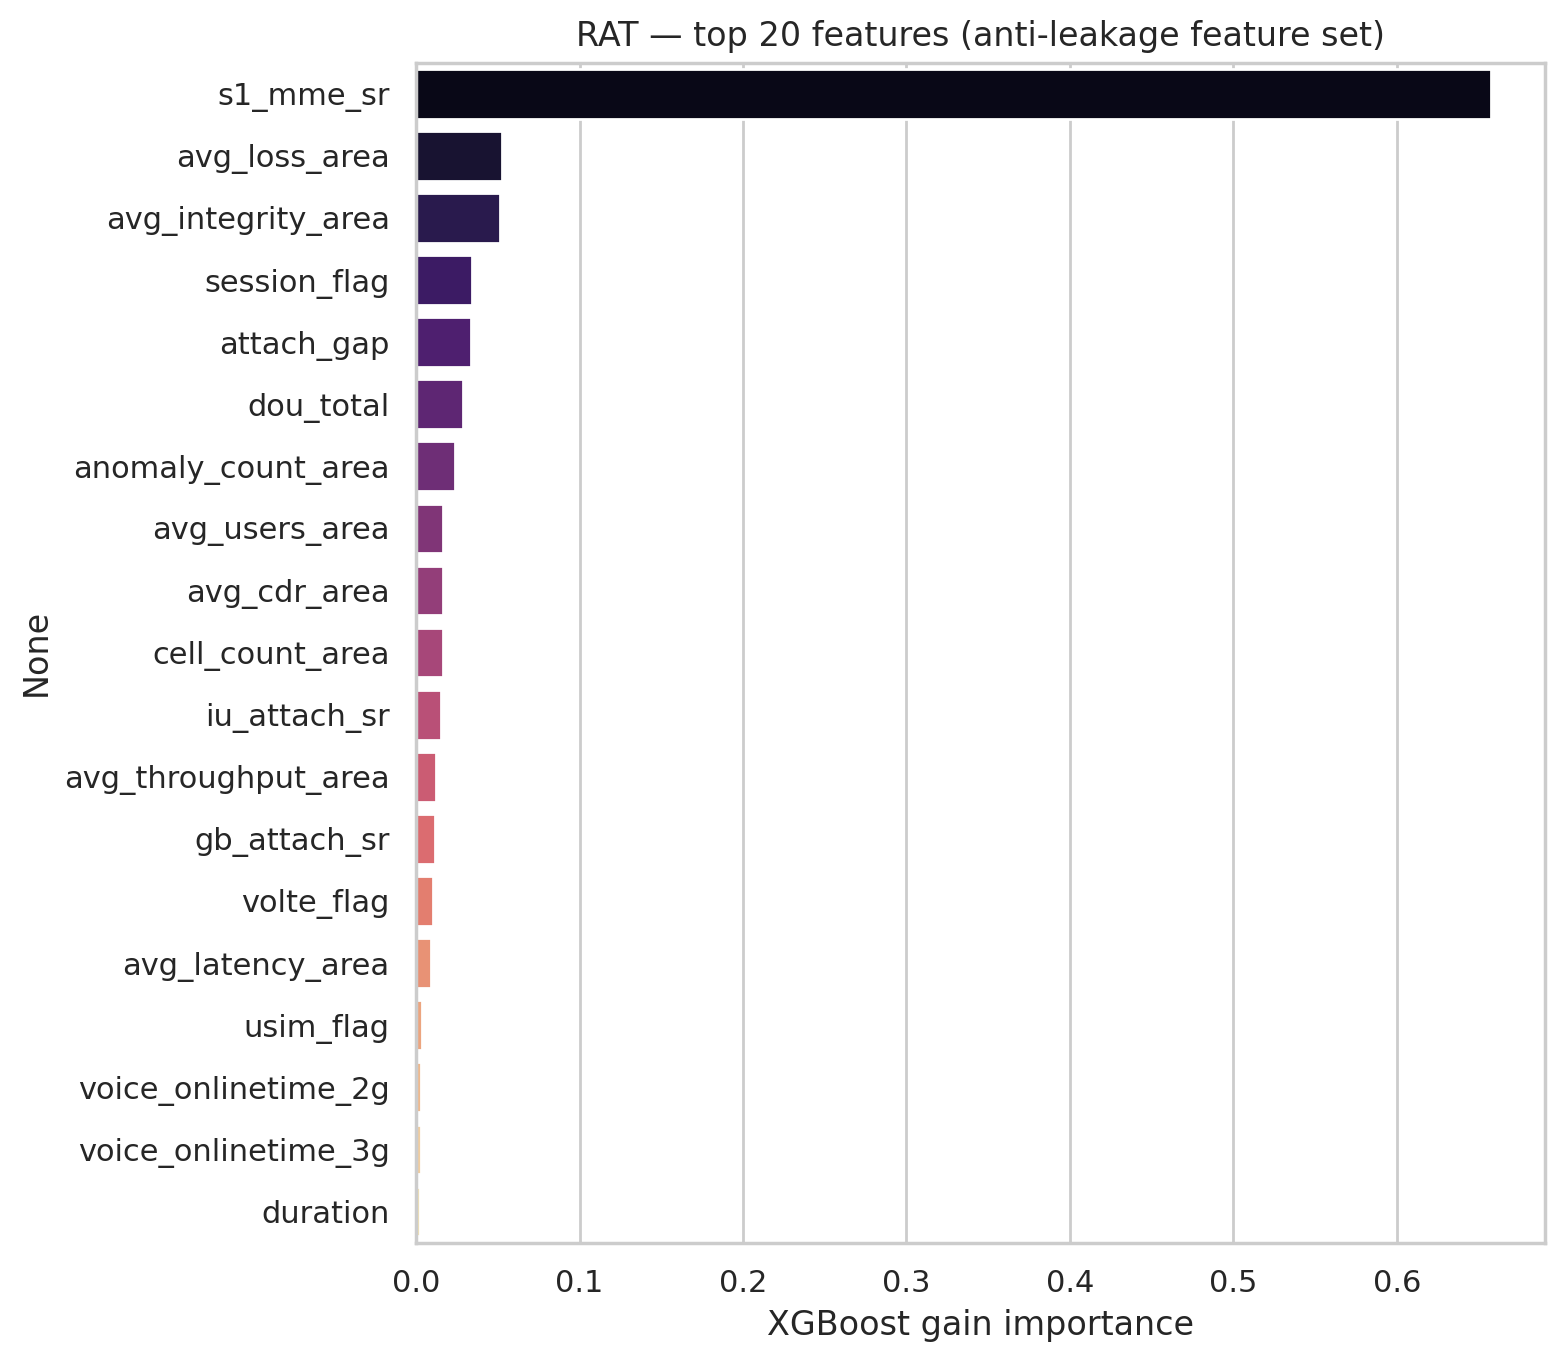

Top features should be behavioral (ARPU, voice/SMS, duration, location, device-age)  NOT raw RAT counters or shares.


In [9]:
imp = (pd.Series(model.feature_importances_, index=feat_cols)
         .sort_values(ascending=False).head(TOP_K_IMPORTANCE))
fig, ax = plt.subplots(figsize=(8,7))
# seaborn ≥0.14: passing `palette` without `hue` is deprecated → map y to hue.
sns.barplot(x=imp.values, y=imp.index, hue=imp.index,
            palette='magma', orient='h', legend=False, ax=ax)
ax.set_title('RAT — top 20 features (anti-leakage feature set)')
ax.set_xlabel('XGBoost gain importance')
plt.tight_layout(); plt.show()
print('Top features should be behavioral (ARPU, voice/SMS, duration, location, '
      'device-age)  NOT raw RAT counters or shares.')

## 8 · Save model + push to MinIO

In [10]:
MODELS = Path('models'); MODELS.mkdir(exist_ok=True)
joblib.dump(model, MODELS/RAT_MODEL_FNAME)
joblib.dump(feat_cols, MODELS/RAT_FEATS_FNAME)

card = (
    f'# RAT Underservice v3 Model Card\n\n'
    f'## Purpose\n'
    f'Predict subscriber RAT-underservice (4G-capable but stuck on 2G/3G traffic) '
    f'from behavioral / device features when the formula inputs '
    f'(`is_4g_capable`, `traffic_share_4g`) are unavailable, stale, or for '
    f'newly-onboarded subscribers. Used by `pb-churn-prevention`.\n\n'
    f'## Anti-leakage policy\n'
    f'- Excluded label inputs: `is_4g_capable`, `traffic_share_4g`.\n'
    f'- Excluded proxies: other `traffic_share_*`, raw `traffic_{{2,3,4,5}}g`, '
    f'`data_intensity`, `usim_bottleneck`, `highest_rat`.\n'
    f'- Features retained ({len(feat_cols)}): {feat_cols}\n\n'
    f'## Training\n'
    f'- XGBoost: ≤{XGB_N_ESTIMATORS} rounds, depth={XGB_MAX_DEPTH}, '
    f'lr={XGB_LEARNING_RATE}, subsample={XGB_SUBSAMPLE}, '
    f'colsample={XGB_COLSAMPLE}, reg_lambda={XGB_REG_LAMBDA}, gamma={XGB_GAMMA}, '
    f'scale_pos_weight={spw:.2f}.\n'
    f'- Early stopping at best val AUC; `best_iteration={best_it}`, '
    f'`best_val_auc={best_auc}`.\n\n'
    f'## Random split\n'
    f'- ROC-AUC: {m_random["ROC_AUC"]:.4f}\n- F1@{DECISION_THRESHOLD}: {m_random["F1@0.5"]:.4f}\n\n'
    f'## Temporal hold-out ({", ".join(m_temp["months"])}, n={m_temp["holdout_size"]:,})\n'
    f'- ROC-AUC: {m_temp["ROC_AUC"]:.4f}\n- F1@{DECISION_THRESHOLD}: {m_temp["F1@0.5"]:.4f}\n\n'
    f'## 5-fold stratified CV (honesty check, n={m_cv["subsample_size"]:,})\n'
    f'- Mean ROC-AUC: {m_cv["cv_roc_auc_mean"]:.4f} ± {m_cv["cv_roc_auc_std"]:.4f}\n'
    f'- Mean PR-AUC:  {m_cv["cv_pr_auc_mean"]:.4f}\n\n'
    f'## Caveat\n'
    f'If random / temporal / CV all report ROC-AUC > 0.995, residual leakage is '
    f'almost certain — re-inspect the feature set against the label formula.\n'
)
(MODELS/RAT_CARD_FNAME).write_text(card); print(card)
for fn in [RAT_MODEL_FNAME, RAT_FEATS_FNAME, RAT_CARD_FNAME]:
    s3.put_object(Bucket='curated', Key=f'models/{fn}', Body=(MODELS/fn).read_bytes())
    print(f'  ↑ curated/models/{fn}')

# RAT Underservice v3 Model Card

## Purpose
Predict subscriber RAT-underservice (4G-capable but stuck on 2G/3G traffic) from behavioral / device features when the formula inputs (`is_4g_capable`, `traffic_share_4g`) are unavailable, stale, or for newly-onboarded subscribers. Used by `pb-churn-prevention`.

## Anti-leakage policy
- Excluded label inputs: `is_4g_capable`, `traffic_share_4g`.
- Excluded proxies: other `traffic_share_*`, raw `traffic_{2,3,4,5}g`, `data_intensity`, `usim_bottleneck`, `highest_rat`.
- Features retained (19): ['volte_flag', 'usim_flag', 'dou_total', 'duration', 'voice_onlinetime_3g', 'voice_onlinetime_2g', 's1_mme_sr', 'iu_attach_sr', 'gb_attach_sr', 'session_flag', 'attach_gap', 'avg_integrity_area', 'avg_cdr_area', 'avg_throughput_area', 'avg_users_area', 'avg_latency_area', 'avg_loss_area', 'cell_count_area', 'anomaly_count_area']

## Training
- XGBoost: ≤800 rounds, depth=6, lr=0.05, subsample=0.8, colsample=0.8, reg_lambda=1.0, gamma=0.1, scale_pos_weig

---
## Done · register